# Entrega 1 — Caracterização dos Dados
**Aluno:** Yuri Lucas Luz da Silva — Matrícula: 2223481

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, requests, json
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../data', exist_ok=True)

URLS = {
    '../data/sinistros.geojson': 'https://dados.fortaleza.ce.gov.br/dataset/76c32db6-97b4-439a-9f12-c0f6413b2013/resource/75f7e594-cab6-4907-b682-9b6af11ebc2c/download/sinistros-2015-2024.geojson',
    '../data/semaforos.geojson': 'https://dados.fortaleza.ce.gov.br/dataset/c529ba45-27ae-4d3a-8f70-76019a87edba/resource/4e4a18a1-86cc-48a1-b631-3ef636b455ee/download/dadosabertos_semaforosctafor.geojson',
}

for path, url in URLS.items():
    if not os.path.exists(path):
        print(f'Baixando {os.path.basename(path)}...')
        r = requests.get(url, verify=False, stream=True, timeout=120)
        with open(path, 'wb') as f:
            for chunk in r.iter_content(256*1024): f.write(chunk)
        print(f'  {os.path.getsize(path)/1e6:.1f} MB')
    else:
        print(f'OK  {os.path.basename(path)}')

Baixando sinistros.geojson...


  85.4 MB
OK  semaforos.geojson


---
## 1. Sinistros de Trânsito (2015–2024)

In [2]:
sin = gpd.read_file('../data/sinistros.geojson')

# coluna HORA é OGR time type — carrega do JSON bruto
with open('../data/sinistros.geojson') as f:
    feats = json.load(f)['features']
sin['HORA'] = [ft['properties'].get('HORA') for ft in feats]

print(f'Registros : {len(sin):,}')
print(f'Colunas   : {len(sin.columns)}')
print(f'Período   : {sin.ANO.min()} – {sin.ANO.max()}')
print()
print(sin.dtypes.to_string())

Skipping field HORA: unsupported OGR type: 10


Registros : 130,823
Colunas   : 28
Período   : 2015 – 2024

COD_ACIDENTE         object
DIA                   int32
MES                   int32
ANO                   int32
LOG1                 object
LOG2                 object
NUMERO              float64
LATITUDE            float64
LONGITUDE           float64
TIPOCRUZAMENTO       object
CONTROLETRAFEGO      object
USOSOLO              object
NATUREZA             object
SEVERIDADE           object
MORTOS                int32
FERIDOS               int32
ILESOS                int32
AUTOMOVEL             int32
ONIBUS                int32
BICICLETA             int32
CAMINHAO              int32
MICROONIBUS           int32
CICLOMOTOR            int32
MOTOCICLETA           int32
TRACAOANIMAL          int32
TREM                  int32
geometry           geometry
HORA                 object


In [3]:
miss = sin.isnull().mean().mul(100).round(1)
miss = miss[miss > 0].sort_values(ascending=False)
print('Valores ausentes (%):')
print(miss.to_string() if len(miss) else 'Nenhum')

Valores ausentes (%):
NUMERO    50.0


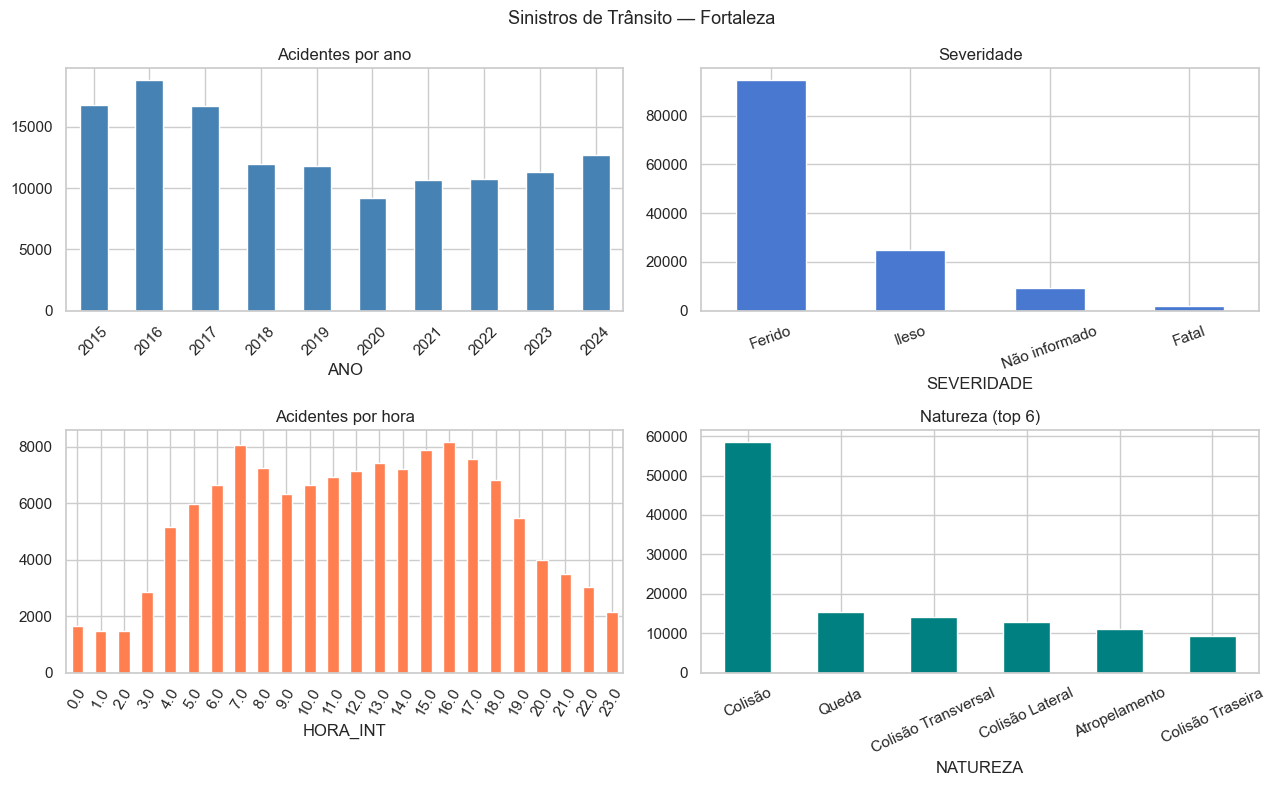

In [4]:
sin['HORA_INT'] = sin['HORA'].str[:2].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sin.groupby('ANO').size().plot.bar(ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Acidentes por ano'); axes[0,0].tick_params(axis='x', rotation=45)

sin['SEVERIDADE'].value_counts().plot.bar(ax=axes[0,1], edgecolor='white')
axes[0,1].set_title('Severidade'); axes[0,1].tick_params(axis='x', rotation=20)

sin.groupby('HORA_INT').size().plot.bar(ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Acidentes por hora'); axes[1,0].tick_params(axis='x', rotation=60)

sin['NATUREZA'].value_counts().head(6).plot.bar(ax=axes[1,1], color='teal', edgecolor='white')
axes[1,1].set_title('Natureza (top 6)'); axes[1,1].tick_params(axis='x', rotation=25)

plt.suptitle('Sinistros de Trânsito — Fortaleza', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Parque Semafórico

In [5]:
sem = gpd.read_file('../data/semaforos.geojson')

print(f'Registros : {len(sem):,}')
print(f'Colunas   : {len(sem.columns)}')
print()
print(sem.dtypes.to_string())

Registros : 1,231
Colunas   : 26

CÓDIGO                            object
CRUZAMENTO                        object
STATUS                            object
DATA_IMPLANTAÇÃO                  object
DATA_DESATIVAÇÃO                  object
DATA_REATIVAÇÃO                   object
GRUPO                             object
MODO_CONTROLE                     object
QUANT_GF_T                       float64
QUANT_GF_I                       float64
QUANT_GF_PEDESTRE                float64
QUANT_GF_CICLISTA                float64
QUANT_BOTOEIRA                   float64
QUANT_BOTOEIRAS_SONORAS          float64
BOTOEIRA NA NOVA RESOLUÇÃO        object
GF_LED                            object
MOTOBOX                           object
SEMÁFORO_EXCLUSIVO_PEDESTRE       object
SEMÁFORO_VEIC_EST_P_PEDESTRE      object
SEMÁFORO_CARONA                   object
ESTÁGIOS                         float64
BAIRRO                            object
REGIONAL                          object
LATITUDE               

In [6]:
miss_s = sem.isnull().mean().mul(100).round(1)
miss_s = miss_s[miss_s > 0].sort_values(ascending=False)
print('Valores ausentes (%):')
print(miss_s.to_string() if len(miss_s) else 'Nenhum')

Valores ausentes (%):
DATA_REATIVAÇÃO                 95.4
BOTOEIRA NA NOVA RESOLUÇÃO      92.7
DATA_DESATIVAÇÃO                88.3
DATA_IMPLANTAÇÃO                30.5
MOTOBOX                         11.7
QUANT_GF_T                      11.6
QUANT_GF_CICLISTA               11.6
QUANT_BOTOEIRA                  11.6
QUANT_GF_PEDESTRE               11.6
QUANT_GF_I                      11.6
SEMÁFORO_EXCLUSIVO_PEDESTRE     11.6
SEMÁFORO_VEIC_EST_P_PEDESTRE    11.6
QUANT_BOTOEIRAS_SONORAS         11.6
GF_LED                          11.6
SEMÁFORO_CARONA                 11.6
ESTÁGIOS                        11.6
GRUPO                           11.5
MODO_CONTROLE                   11.5


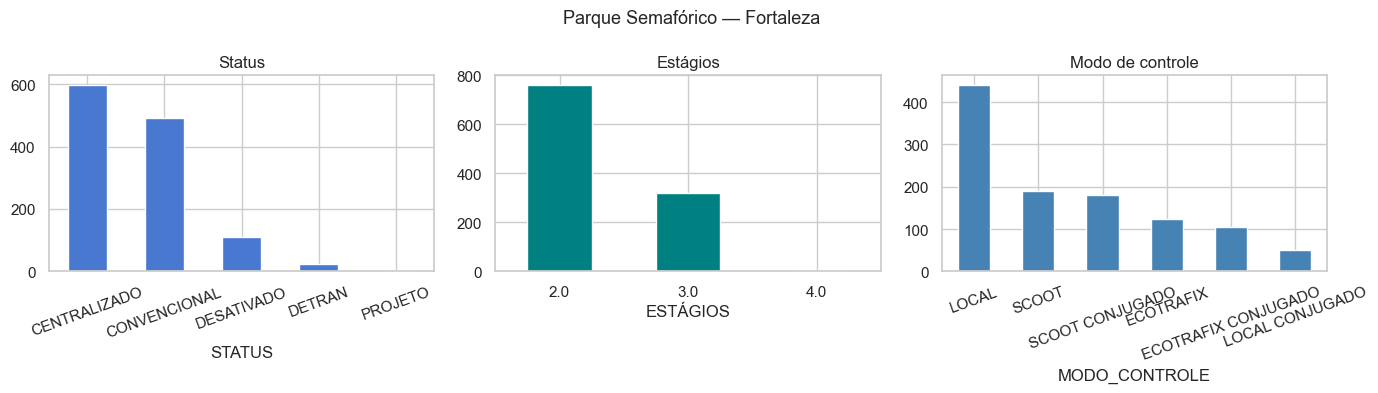

In [7]:
col_est = next((c for c in sem.columns if 'EST' in c.upper() and 'GIO' in c.upper()), None)
col_impl = next((c for c in sem.columns if 'IMPLANT' in c.upper()), None)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sem['STATUS'].value_counts().plot.bar(ax=axes[0], edgecolor='white')
axes[0].set_title('Status'); axes[0].tick_params(axis='x', rotation=20)

if col_est:
    sem[col_est].value_counts().sort_index().plot.bar(ax=axes[1], color='teal', edgecolor='white')
    axes[1].set_title('Estágios'); axes[1].tick_params(axis='x', rotation=0)

sem['MODO_CONTROLE'].value_counts().plot.bar(ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Modo de controle'); axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Parque Semafórico — Fortaleza', fontsize=13)
plt.tight_layout()
plt.show()

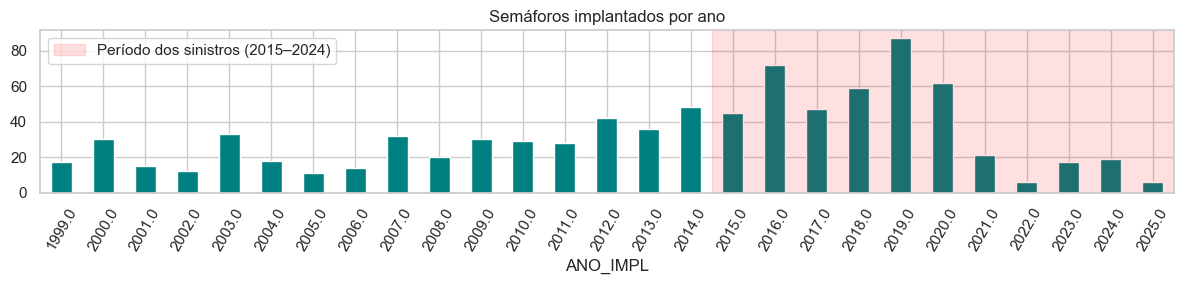

Implantados durante 2015–2024: 435 (50.8%)
→ Esses equipamentos exigem reconstrução histórica no spatial join.


In [8]:
if col_impl:
    sem['ANO_IMPL'] = pd.to_datetime(sem[col_impl], dayfirst=True, errors='coerce').dt.year
    impl = sem.dropna(subset=['ANO_IMPL']).query('ANO_IMPL >= 1990')

    fig, ax = plt.subplots(figsize=(12, 3))
    impl.groupby('ANO_IMPL').size().plot.bar(ax=ax, color='teal', edgecolor='white')
    ax.set_title('Semáforos implantados por ano'); ax.tick_params(axis='x', rotation=60)

    anos = sorted(impl['ANO_IMPL'].unique())
    if 2015 in anos:
        ax.axvspan(anos.index(2015) - 0.5, len(anos) - 0.5,
                   alpha=0.12, color='red', label='Período dos sinistros (2015–2024)')
        ax.legend()

    plt.tight_layout()
    plt.show()

    n = impl['ANO_IMPL'].between(2015, 2024).sum()
    print(f'Implantados durante 2015–2024: {n} ({n/len(impl)*100:.1f}%)')
    print('→ Esses equipamentos exigem reconstrução histórica no spatial join.')